In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

def million_formatter(x, pos):
    """Formatador para milhões"""
    return '%1.0fM' % (x * 1e-6)

def billion_formatter(x, pos):
    """Formatador para milhões"""
    return '%1.0fB' % (x * 1e-9)

<h1>Importando a base</h1>

In [124]:
pd.set_option('future.no_silent_downcasting', True)

regioes = pd.read_excel('base_consolidada.xlsx', sheet_name='regioes')  # SERASA 2026
inadimplentes = pd.read_excel('base_consolidada.xlsx', sheet_name='inadimplentes').replace('n.d.', np.nan)  # SERASA 2026
setores = pd.read_excel('base_consolidada.xlsx', sheet_name='setores').replace('n.d.', np.nan)  # SERASA 2026
urbanizacao = pd.read_excel('base_consolidada.xlsx', sheet_name='urbanizacao')  # IBGE 2010
custo_de_vida = pd.read_excel('base_consolidada.xlsx', sheet_name='custo_de_vida')  # https://tableaubrasil.com.br/financeiro/custo-de-vida-nos-estados-do-brasil
populacao_por_regiao = pd.read_excel('base_consolidada.xlsx', sheet_name='populacao_por_regiao')  # IBGE 2025
populacao_por_estado = pd.read_excel('base_consolidada.xlsx', sheet_name='populacao_por_estado')  # IBGE 2025
taxa_de_desemprego_SP = pd.read_excel('base_consolidada.xlsx', sheet_name='taxa_de_desemprego_SP')

<h1>Introdução</h1>
<ul>
    <li>A maior oferta e facilidade do crédito digital em áreas urbanas aumentam o uso impulsivo, elevando o endividamento jovem?</li>
    <!-- Censo 2010 - IBGE -->
    <li>Regiões com maior custo de vida exigem mais gastos, levando jovens a recorrerem ao crédito e se endividarem?</li>
    <li>Jovens com pouco conhecimento financeiro tendem a usar crédito sem planejamento, acumulando dívidas?</li>
    <li>A pressão por padrões de consumo leva jovens a gastar mais e recorrer ao crédito para sustentar esse comportamento?</li>
    <li>A instabilidade no mercado de trabalho entre jovens contribui para o uso recorrente de crédito e, consequentemente, para o endividamento?</li>
</ul>

<h1>Consumidores inadimplentes</h1>
<ul>
    <li><strong>Inadimplência:</strong> Não pagamento de uma obrigação financeira no prazo.</li>
    <li><strong>Dívida negativada:</strong> Uma dívida negativada ocorre quando o não pagamento de uma conta resulta no registro do CPF em órgãos de proteção ao crédito (Serasa, SPC, Boa Vista), restringindo acesso a crédito.</li>
</ul>

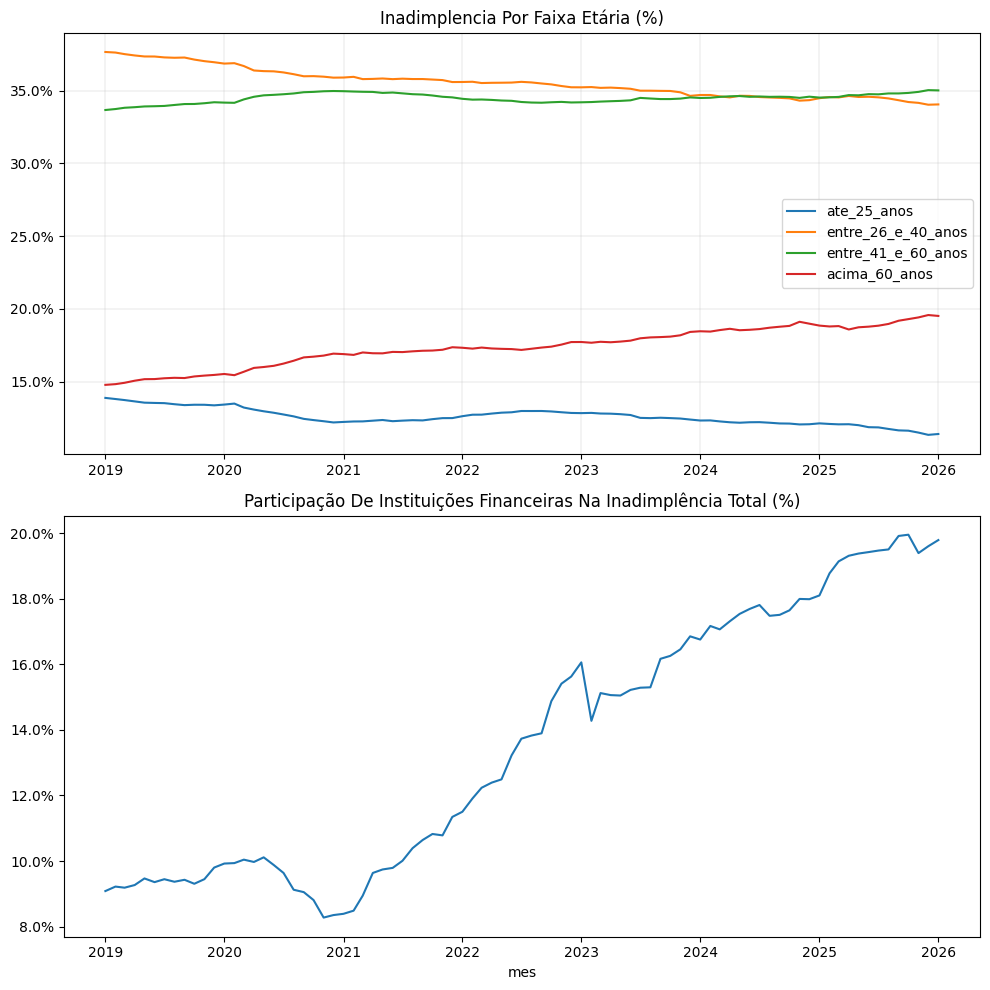

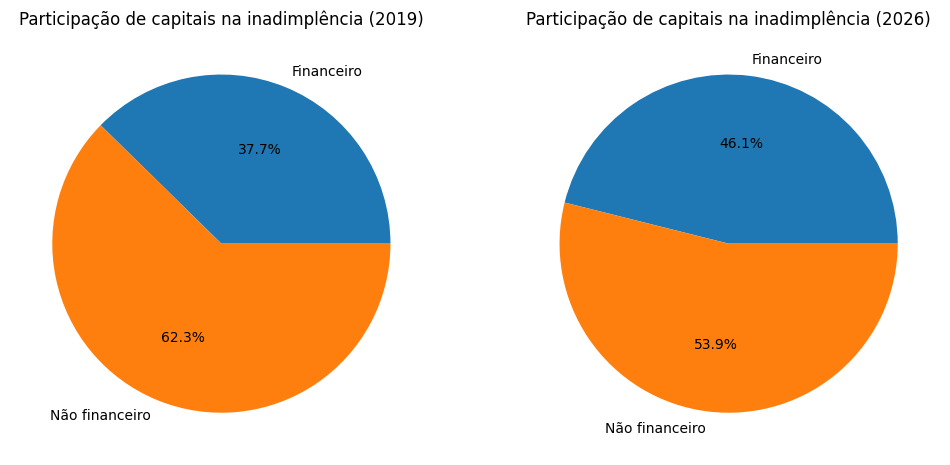

In [150]:
plot = inadimplentes[['mes', 'consumidores_inadimplentes_MI', 'ate_25_anos', 'entre_26_e_40_anos', 'entre_41_e_60_anos', 'acima_60_anos']].copy()
plot['ate_25_anos'] = plot['ate_25_anos'] / plot['consumidores_inadimplentes_MI']
plot['entre_26_e_40_anos'] = plot['entre_26_e_40_anos'] / plot['consumidores_inadimplentes_MI']
plot['entre_41_e_60_anos'] = plot['entre_41_e_60_anos'] / plot['consumidores_inadimplentes_MI']
plot['acima_60_anos'] = plot['acima_60_anos'] / plot['consumidores_inadimplentes_MI']


fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# inadimplência por faixa etária
sns.lineplot(plot, x='mes', y='ate_25_anos', label='ate_25_anos', ax=axes[0])
sns.lineplot(plot, x='mes', y='entre_26_e_40_anos', label='entre_26_e_40_anos', ax=axes[0])
sns.lineplot(plot, x='mes', y='entre_41_e_60_anos', label='entre_41_e_60_anos', ax=axes[0])
sns.lineplot(plot, x='mes', y='acima_60_anos', label='acima_60_anos', ax=axes[0])
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(1))
axes[0].set_title('Inadimplencia Por Faixa Etária (%)')
axes[0].set_ylabel('')
axes[0].set_xlabel('')
axes[0].grid(lw=.2)

sns.lineplot(setores[['mes', 'financeiras_F']][setores.mes.dt.year >= 2019], x='mes', y='financeiras_F', ax=axes[1])
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(1))
axes[1].set_title('Participação De Instituições Financeiras Na Inadimplência Total (%)'.title())
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot = setores[['mes', 'total_financeiro_AF', 'total_nao_financeiro_BCDEGHI']].copy()
plot['ano'] = plot.mes.dt.year
plot = plot.groupby('ano')[['total_financeiro_AF', 'total_nao_financeiro_BCDEGHI']].mean()
axes[0].pie(plot.loc[2019], labels=['Financeiro', 'Não financeiro'], autopct='%1.1f%%')
axes[0].set_title('Participação de capitais na inadimplência (2019)')
axes[1].pie(plot.loc[2026], labels=['Financeiro', 'Não financeiro'], autopct='%1.1f%%')
axes[1].set_title('Participação de capitais na inadimplência (2026)')
plt.show()

# participacao_2026 = plot['total_financeiro_AF'].iloc[-1]
# participacao_2018 = plot['total_financeiro_AF'].iloc[0]
# print(f'A participação do capital financeiro na inadimplência do consumidor cresceu {(participacao_2026 - participacao_2018) * 100:.1f}% entre os anos de 2018 e 2026')

<h2>1. A maior oferta e facilidade do crédito digital em áreas urbanas aumentam o uso impulsivo, elevando o endividamento jovem?</h3>

In [160]:
regioes_2026 = regioes[regioes.mes.dt.year == 2026].reset_index(drop=True).drop('mes', axis=1)[['regiao', 'estado', 'estado_sigla', 'consumidores_inadimplentes', 'dividas_negativadas', 'valor_dividas_negativadas', 'divida_media_por_cpf', 'valor_divida_media', 'ticket_medio', 'porcentagem_adultos']]
regioes_2026 = pd.merge(regioes_2026, populacao_por_estado, on='estado')
regioes_2026['proporcao_consumidores_inadimplentes'] = regioes_2026['consumidores_inadimplentes'] / regioes_2026['populacao']
proporcao_inadimplencia = regioes_2026.sort_values('proporcao_consumidores_inadimplentes', ascending=False)[['estado', 'proporcao_consumidores_inadimplentes']]

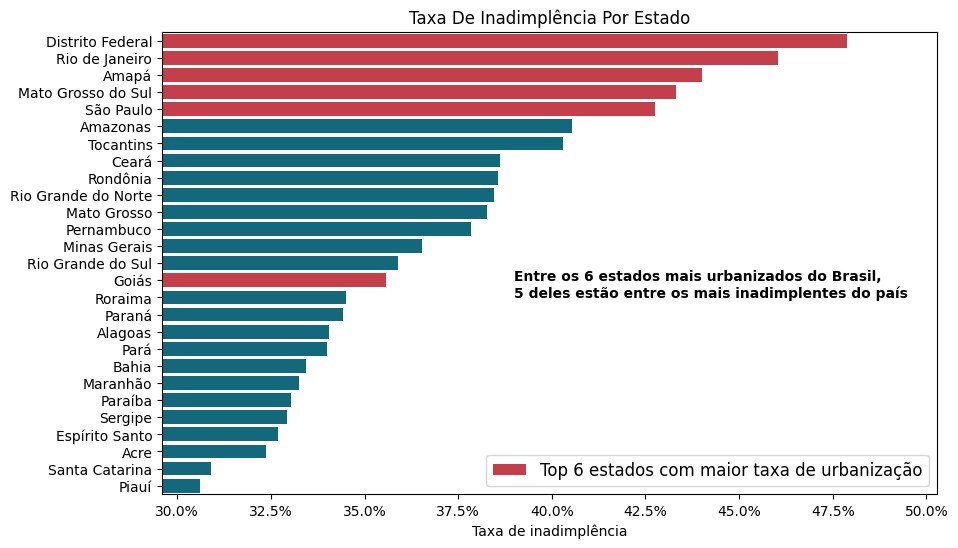

In [195]:
top_6_urbanizados = urbanizacao.iloc[0:6, 0:2]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    proporcao_inadimplencia, 
    y='estado', 
    x='proporcao_consumidores_inadimplentes', 
    orient='h', 
    ax=ax,
    color='#03738C'
)
sns.barplot(
    proporcao_inadimplencia[proporcao_inadimplencia.estado.isin(top_6_urbanizados.estado.values)], 
    y='estado', 
    x='proporcao_consumidores_inadimplentes', 
    orient='h', 
    ax=ax,
    color='#D92938',
    label='Top 6 estados com maior taxa de urbanização'
)
ax.xaxis.set_major_formatter(ticker.PercentFormatter(1))
ax.set_title('Taxa De Inadimplência Por Estado')
ax.set_ylabel('')
ax.set_xlabel('Taxa de inadimplência')
ax.set_xlim(xmin=proporcao_inadimplencia.proporcao_consumidores_inadimplentes.min() - 0.01)
ax.legend(fontsize=12)
ax.annotate('Entre os 6 estados mais urbanizados do Brasil, \n5 deles estão entre os mais inadimplentes do país', (0.39, 15), weight='bold')
plt.show()

<h2>2. Regiões com maior custo de vida exigem mais gastos, levando jovens a recorrerem ao crédito e se endividarem?</h3>

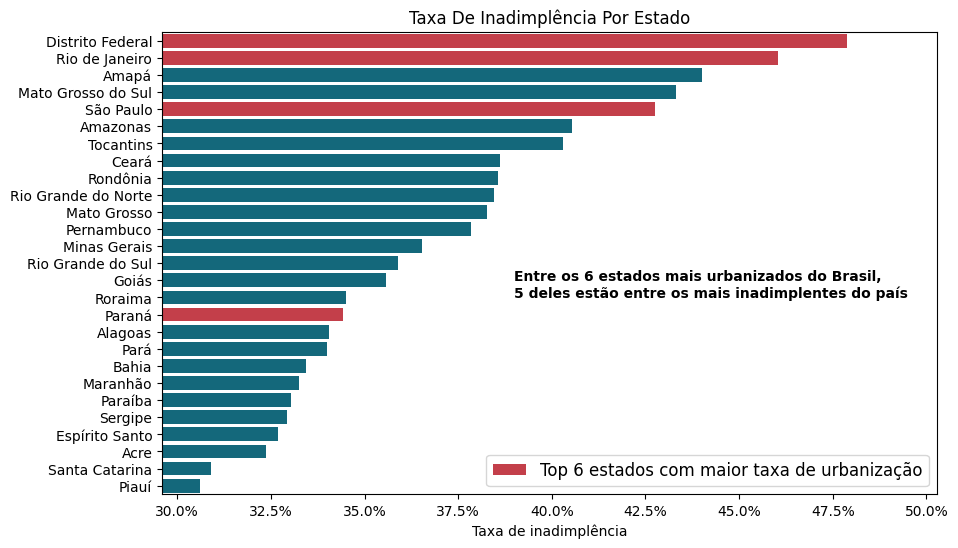

In [196]:
top_4_custo_de_vida = custo_de_vida.sort_values('custo_de_vida', ascending=False).head(4)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    proporcao_inadimplencia, 
    y='estado', 
    x='proporcao_consumidores_inadimplentes', 
    orient='h', 
    ax=ax,
    color='#03738C'
)
sns.barplot(
    proporcao_inadimplencia[proporcao_inadimplencia.estado.isin(top_4_custo_de_vida.estado.values)], 
    y='estado', 
    x='proporcao_consumidores_inadimplentes', 
    orient='h', 
    ax=ax,
    color='#D92938',
    label='Top 6 estados com maior taxa de urbanização'
)
ax.xaxis.set_major_formatter(ticker.PercentFormatter(1))
ax.set_title('Taxa De Inadimplência Por Estado')
ax.set_ylabel('')
ax.set_xlabel('Taxa de inadimplência')
ax.set_xlim(xmin=proporcao_inadimplencia.proporcao_consumidores_inadimplentes.min() - 0.01)
ax.legend(fontsize=12)
ax.annotate('Três dos 4 estados mais , \n5 deles estão entre os mais inadimplentes do país', (0.39, 15), weight='bold')
plt.show()

<h3>3. Jovens com pouco conhecimento financeiro tendem a usar crédito sem planejamento, acumulando dívidas?</h3>

<Axes: xlabel='mes', ylabel='consumidores_inadimplentes_MI'>

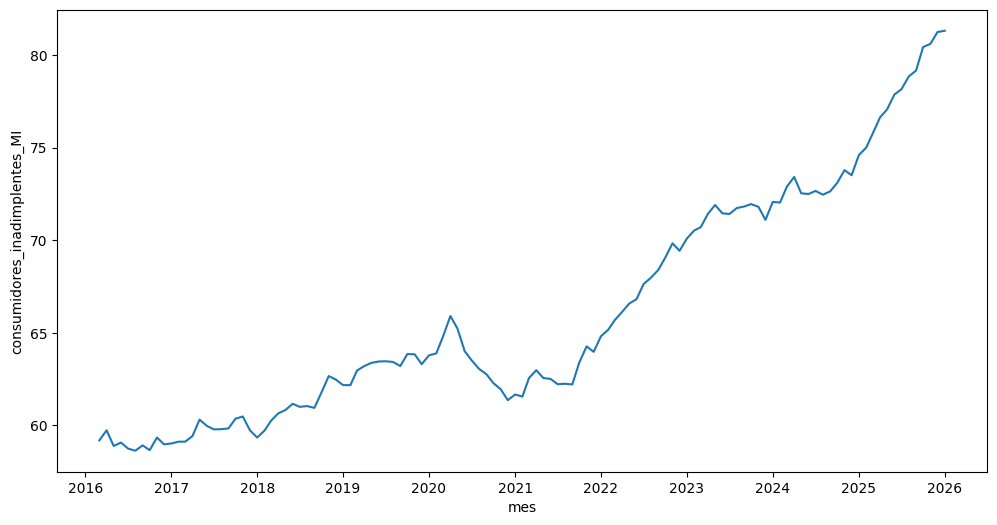

In [144]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(inadimplentes, x='mes', y='consumidores_inadimplentes_MI', ax=ax)